In [58]:
pwd

'/Users/ashlynjorgenson/Desktop/python_decal_fa25/ashlyn/homework9'

In [59]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

In [60]:
df=pd.read_csv('../../course_assignments/homework9/solar_system.csv')

In [61]:
print(df.head())
print(df.tail())
print(df.shape) # 20 rows, 11 columns
print(list(df.columns))
print(list(df.index))

                Attribute Mercury  Venus  Earth   Moon   Mars Jupiter  Saturn  \
0          Mass (10^24kg)   0.330   4.87   5.97  0.073  0.642    1898     568   
1           Diameter (km)    4879  12104  12756   3475   6792  142984  120536   
2        Density (kg/m^3)    5429   5243   5514   3340   3934    1326     687   
3         Gravity (m/s^2)     3.7    8.9    9.8    1.6    3.7    23.1     9.0   
4  Escape Velocity (km/s)     4.3   10.4   11.2    2.4    5.0    59.5    35.5   

  Uranus Neptune   Pluto  
0   86.8     102  0.0130  
1  51118   49528    2376  
2   1270    1638    1850  
3    8.7    11.0     0.7  
4   21.3    23.5     1.3  
                  Attribute Mercury Venus Earth Moon  Mars  Jupiter   Saturn  \
15     Mean Temperature (C)     167   464    15  -20   -65     -110     -140   
16  Surface Pressure (bars)       0    92     1    0  0.01  Unknown  Unknown   
17          Number of Moons       0     0     1    0     2       95      274   
18             Ring System?    

In [62]:
df2=df.set_index('Attribute')

In [63]:
df2.loc['Orbital Period (days)']
df2.loc['Perihelion (10^6 km)']
df2.loc['Aphelion (10^6 km)']

orbital_period = df2.loc['Orbital Period (days)'].astype(float)
perihelion = df2.loc['Perihelion (10^6 km)'].astype(float)
aphelion = df2.loc['Aphelion (10^6 km)'].astype(float)

earth_orbital_period=float(orbital_period['Earth'])
print(earth_orbital_period)

365.2


In [64]:
print(df['Attribute'].tolist())

['Mass (10^24kg)', 'Diameter (km)', 'Density (kg/m^3)', 'Gravity (m/s^2)', 'Escape Velocity (km/s)', 'Rotation Period (hours)', 'Length of Day (hours)', 'Distance from Sun (10^6 km)', 'Perihelion (10^6 km)', 'Aphelion (10^6 km)', 'Orbital Period (days)', 'Orbital Velocity (km/s)', 'Orbital Inclination (deg)', 'Orbital Eccentricity', 'Obliquity to Orbit (deg)', 'Mean Temperature (C)', 'Surface Pressure (bars)', 'Number of Moons', 'Ring System?', 'Global Magnetic Field?']


In [65]:
# perihelion is the point of an object's orbit that it is closest to its star
# aphelion is when it is farthest from the sun

In [70]:
semi_major_axis = (perihelion+aphelion)/2

In [71]:
df2=df.set_index('Attribute')
df2.loc['Semi-Major Axis (AU)'] = semi_major_axis

In [72]:
print(df2.tail())
print(df2.shape) # 21 rows, 10 columns

                        Mercury  Venus  Earth    Moon   Mars  Jupiter  \
Attribute                                                               
Surface Pressure (bars)       0     92      1       0   0.01  Unknown   
Number of Moons               0      0      1       0      2       95   
Ring System?                 No     No     No      No     No      Yes   
Global Magnetic Field?      Yes     No    Yes      No     No      Yes   
Semi-Major Axis (AU)       57.9  108.2  149.6  0.3845  228.0    778.5   

                          Saturn   Uranus  Neptune    Pluto  
Attribute                                                    
Surface Pressure (bars)  Unknown  Unknown  Unknown  0.00001  
Number of Moons              274       28       16        5  
Ring System?                 Yes      Yes      Yes       No  
Global Magnetic Field?       Yes      Yes      Yes  Unknown  
Semi-Major Axis (AU)     1432.05  2867.05   4515.0  5906.35  
(21, 10)


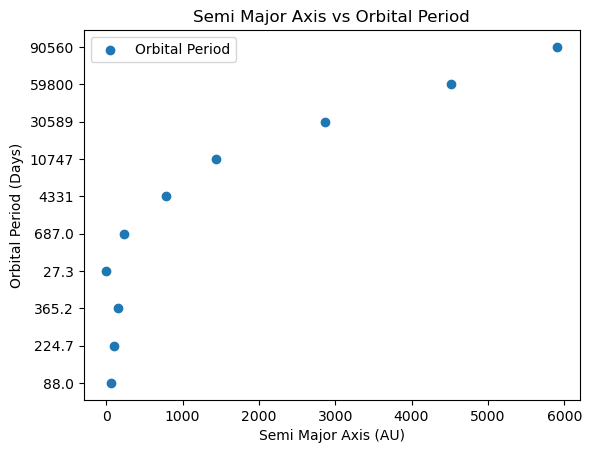

In [75]:
x=df2.loc["Semi-Major Axis (AU)"]
y=df2.loc["Orbital Period (days)"]
plt.scatter(x, y, label= "Orbital Period")
plt.xlabel("Semi Major Axis (AU)")
plt.ylabel("Orbital Period (Days)")
plt.legend()
plt.title("Semi Major Axis vs Orbital Period")
plt.show()

In [93]:
def keplers_third_law(a, m):
    return m * a ** 1.5

x = df2.loc['Semi-Major Axis (AU)'].astype(float)
y = df2.loc['Orbital Period (days)'].astype(float)/365

In [94]:
popt, pcov = curve_fit(keplers_third_law, x, y, p0=[1])
m_fit = popt[0]
print(f"Fitted Model:Orbital Period = {m_fit:.2f} * a ^ 1.5")

residuals = y - keplers_third_law(x, m_fit)
chi2 = np.sum(residuals**2)
dof = len(x) - len(popt) 
chi2_reduced = chi2 / dof

print(f"Reduced chi-squared: {chi2_reduced:.2f}")

Fitted Model:Orbital Period = 0.00 * a ^ 1.5
Reduced chi-squared: 0.31


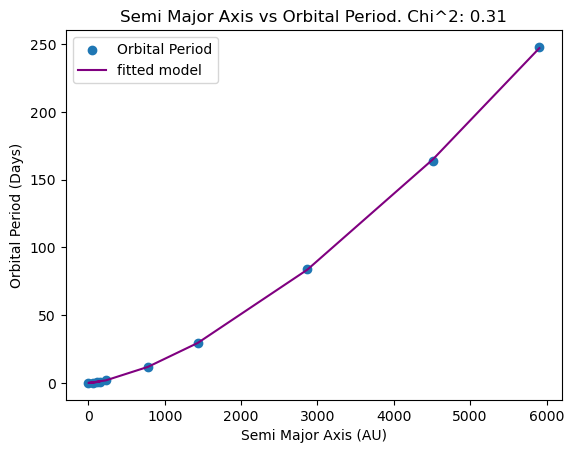

In [97]:
x=x
y=y
plt.scatter(x, y, label= "Orbital Period")
plt.plot(x, keplers_third_law(x, m_fit), color="purple", label="fitted model")
plt.xlabel("Semi Major Axis (AU)")
plt.ylabel("Orbital Period (Days)")
plt.legend()
plt.title("Semi Major Axis vs Orbital Period. Chi^2: 0.31")
plt.show()

In [98]:
df.to_csv("planet_data_with_semi_major_axis.csv", index=False)